# Step 3. 산불발생 선행기상 및 국지임계치 심화분석

직전 24·48·72시간과 D-1~D-3 선행 기상, 번지유형, 캐나다 지수 분석에 필요한 자료를 준비한다.

## 현재 구현 범위

이 노트북은 **원천 데이터 경로 확인, 로딩, 필수 스키마 검증, 시간 파싱,
기본 행 수 감사**까지 구현한다. 통계 분석과 시각화는 이후 셀에서 이어서 작성한다.

공통 데이터 계약은 `README.md`를 따른다. Step 2~6에서 캐나다 지수를 사건 시각에
결합할 때는 12시 이전이면 전일 정오, 12시 이후이면 당일 정오 자료만 사용한다.

결과 해석은 이 노트북에 작성하지 않는다. 결과표와 플롯을 함께 검토한 해석,
한계와 다음 코드 반영사항은 대응 `진행예정로그.md`에만 기록한다.

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd().resolve()
candidates = [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]
REPO_ROOT = next(
    (path for path in candidates if (path / "jsw/강원_재_EDA/re_eda_common.py").exists()),
    Path(r"D:/farm-system-public-02"),
)
MODULE_DIR = REPO_ROOT / "jsw/강원_재_EDA"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from re_eda_common import (
    DATA_PATHS,
    DERIVED_WEATHER_COLUMNS,
    RAW_WEATHER_COLUMNS,
    add_canadian_asof_keys,
    check_sources,
    configure_notebook,
    frame_inventory,
    load_access_lines,
    load_canadian_indices,
    load_dem_metadata,
    load_fire,
    load_grid_bundle,
    load_hourly_weather,
    load_infrastructure,
    load_landcover,
    load_roads,
    load_terrain,
)

configure_notebook()

REPO_ROOT: D:\farm-system-public-02
matplotlib font.family: ['Malgun Gothic']


## 1. 원천 파일 존재 여부

In [2]:
SOURCE_KEYS = ['fire', 'weather_cells', 'weather_grid', 'weather_hourly_derived', 'climate_type', 'canada_ffmc', 'canada_fwi']
source_audit = check_sources(SOURCE_KEYS)
display(source_audit)

,데이터키,존재,크기_MB,경로
0,fire,True,0.39,D:\farm-system-public-02\data\강원도_데이터\강원도_산불발생...
1,weather_cells,True,0.05,D:\farm-system-public-02\data\강원도_날씨데이터\강원도날씨_...
2,weather_grid,True,0.09,D:\farm-system-public-02\data\강원도_날씨데이터\강원도날씨_...
3,weather_hourly_derived,True,438.45,D:\farm-system-public-02\data\학습데이터\기상_시간단위_파생...
4,climate_type,True,0.00,D:\farm-system-public-02\data\강원도_날씨데이터\강원도날씨_...
5,canada_ffmc,True,6.75,D:\farm-system-public-02\data\학습데이터\캐나다_FFMC_선...
6,canada_fwi,True,10.10,D:\farm-system-public-02\data\학습데이터\캐나다_FWI_일단...


## 2. 산불 및 기상격자 로딩

In [3]:
fire, fire_points = load_fire()
grid_bundle = load_grid_bundle()
weather_cells = grid_bundle["cells"]
climate_type = grid_bundle["climate"]
weather_grid = grid_bundle["grid"]

print("산불:", len(fire), "건")
print("좌표 유효 산불:", len(fire_points), "건")
print("발생시각 결측:", int(fire["기준시각"].isna().sum()), "건")
display(fire.head())

산불: 3405 건
좌표 유효 산불: 3405 건
발생시각 결측: 0 건


,fire_id,연도,월,일,시간,진화소요시간(HH),위도,경도,발생지역시도명,발생지역시군구명,발생지역읍면동명,발생지역리명,발생지역번지,발생원인명,피해면적(ha),피해금액,발생일시,기준시각,발생날짜,번지유형
0,F_003556,2020,4,30,18,NaN,37.432421,127.803653,강원특별자치도,원주시,지정면,월송리,산172,NaN,NaN,NaN,2020-04-30 18:00:00,2020-04-30 18:00:00,2020-04-30,임야번지(산)
1,F_006688,2020,4,30,18,NaN,37.432421,127.803653,강원특별자치도,원주시,지정면,월송리,산172,NaN,NaN,NaN,2020-04-30 18:00:00,2020-04-30 18:00:00,2020-04-30,임야번지(산)
2,F_006690,2020,5,1,22,NaN,37.773694,127.446131,강원특별자치도,고성군,토성면,도원리,NaN,NaN,NaN,NaN,2020-05-01 22:00:00,2020-05-01 22:00:00,2020-05-01,일반번지
3,F_007615,2020,1,1,12,NaN,37.761451,128.841125,강원특별자치도,강릉시,성산면,위촌리,877,NaN,NaN,NaN,2020-01-01 12:00:00,2020-01-01 12:00:00,2020-01-01,일반번지
4,F_007616,2020,1,3,12,NaN,37.329735,129.043221,강원특별자치도,삼척시,신기면,대이리,30,NaN,NaN,NaN,2020-01-03 12:00:00,2020-01-03 12:00:00,2020-01-03,일반번지


## 3. 누수 방지 시간기상 파생자료 로딩

In [4]:
hourly_weather = load_hourly_weather(
    derived=True,
    columns=DERIVED_WEATHER_COLUMNS,
)
print("기간:", hourly_weather["일시"].min(), "~", hourly_weather["일시"].max())
print("기상셀 수:", hourly_weather["기상셀ID"].nunique())
display(hourly_weather.head())

기간: 2020-01-01 00:00:00 ~ 2021-12-31 23:00:00
기상셀 수: 92


,기상셀ID,일시,시점_기온_C,시점_풍속_m_s,시점_습도_pct,직전24h_평균풍속,직전24h_최대풍속,직전48h_평균풍속,직전48h_최대풍속,직전24h_평균기온_C,직전24h_평균습도,직전24h_최소습도,직전48h_평균습도,직전48h_최소습도,직전24h_강수량합,직전48h_강수량합,시점_풍향_deg,풍향_sin,풍향_cos,서풍계열_여부,시점_현지기압_hPa,시점_해면기압_hPa,기압변동_3h,D-1_최소습도_pct,D-1_평균습도_pct,D-1_강수량합_mm,D-2_최소습도_pct,D-3_최소습도_pct
0,YD_0001,2020-01-01 00:00:00,-4.18,4.52,29.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,226.26,-0.722485,-0.691387,1,999.82,1021.12,NaN,NaN,NaN,NaN,NaN,NaN
1,YD_0001,2020-01-01 01:00:00,-3.59,4.28,40.85,4.520,4.52,4.520,4.52,-4.1800,29.0000,29.0,29.0000,29.0,0.0,0.0,235.90,-0.828060,-0.560639,1,999.68,1020.90,NaN,NaN,NaN,NaN,NaN,NaN
2,YD_0001,2020-01-01 02:00:00,-2.97,4.01,44.09,4.400,4.52,4.400,4.52,-3.8850,34.9250,29.0,34.9250,29.0,0.0,0.0,243.05,-0.891402,-0.453213,1,999.70,1020.91,NaN,NaN,NaN,NaN,NaN,NaN
3,YD_0001,2020-01-01 03:00:00,-2.79,4.89,50.15,4.270,4.52,4.270,4.52,-3.5800,37.9800,29.0,37.9800,29.0,0.0,0.0,233.54,-0.804272,-0.594261,1,999.58,1020.75,-0.24,NaN,NaN,NaN,NaN,NaN
4,YD_0001,2020-01-01 04:00:00,-2.54,4.32,52.23,4.425,4.89,4.425,4.89,-3.3825,41.0225,29.0,41.0225,29.0,0.0,0.0,245.21,-0.907851,-0.419294,1,999.42,1020.55,-0.26,NaN,NaN,NaN,NaN,NaN


## 4. 캐나다 지수 및 사건별 as-of 키 준비

In [5]:
canadian_indices = load_canadian_indices()
fire = add_canadian_asof_keys(fire, time_column="기준시각")

asof_violations = (
    fire["캐나다지수_기준시각"] > fire["기준시각"]
).sum()
assert asof_violations == 0
display(
    fire[
        [
            "fire_id",
            "기준시각",
            "캐나다지수_기준날짜",
            "캐나다지수_기준시각",
            "캐나다지수_시차시간",
            "캐나다지수_당일사용여부",
        ]
    ].head()
)

,fire_id,기준시각,캐나다지수_기준날짜,캐나다지수_기준시각,캐나다지수_시차시간,캐나다지수_당일사용여부
0,F_003556,2020-04-30 18:00:00,2020-04-30,2020-04-30 12:00:00,6.0,True
1,F_006688,2020-04-30 18:00:00,2020-04-30,2020-04-30 12:00:00,6.0,True
2,F_006690,2020-05-01 22:00:00,2020-05-01,2020-05-01 12:00:00,10.0,True
3,F_007615,2020-01-01 12:00:00,2020-01-01,2020-01-01 12:00:00,0.0,True
4,F_007616,2020-01-03 12:00:00,2020-01-03,2020-01-03 12:00:00,0.0,True


## 5. 선행기상 컬럼 가용성 감사

In [6]:
expected_lead_columns = [
    "직전24h_평균풍속",
    "직전24h_최대풍속",
    "직전48h_평균풍속",
    "직전48h_최대풍속",
    "직전24h_평균습도",
    "직전24h_최소습도",
    "직전48h_평균습도",
    "직전48h_최소습도",
    "직전24h_강수량합",
    "직전48h_강수량합",
    "D-1_최소습도_pct",
    "D-1_평균습도_pct",
    "D-1_강수량합_mm",
    "D-2_최소습도_pct",
    "D-3_최소습도_pct",
]
display(hourly_weather[expected_lead_columns].isna().mean().rename("결측률").to_frame())
print("주의: 직전72h 및 추가 D-2/D-3 집계는 원본 시간자료에서 누수 없이 후속 계산합니다.")

,결측률
직전24h_평균풍속,0.000057
직전24h_최대풍속,0.000057
직전48h_평균풍속,0.000057
직전48h_최대풍속,0.000057
직전24h_평균습도,0.000057
직전24h_최소습도,0.000057
직전48h_평균습도,0.000057
직전48h_최소습도,0.000057
직전24h_강수량합,0.000057
직전48h_강수량합,0.000057


주의: 직전72h 및 추가 D-2/D-3 집계는 원본 시간자료에서 누수 없이 후속 계산합니다.


## 로딩 결과 요약

In [7]:
loaded_frames = {
    "fire": fire,
    "fire_points": fire_points,
    "weather_cells": weather_cells,
    "climate_type": climate_type,
    "weather_grid": weather_grid,
    "hourly_weather": hourly_weather,
    "canadian_indices": canadian_indices,
}
display(frame_inventory(loaded_frames))

,이름,행,열,메모리_MB,CRS
0,fire,3405,25,0.86,NaN
1,fire_points,3405,21,0.78,EPSG:4326
2,weather_cells,92,12,0.05,NaN
3,climate_type,92,3,0.00,NaN
4,weather_grid,92,12,0.01,EPSG:4326
5,hourly_weather,1614048,28,355.57,NaN
6,canadian_indices,67252,16,8.66,NaN


## 다음 구현 범위

직전72시간·D-1~D-3 파생을 보강하고, 매칭 대조군 기준 상대 분위수와 지역·번지별 임계치를 계산한다.

현재 노트북은 로딩과 입력 감사까지만 실행한다. 이후 분석 셀에서도
`README.md`의 미래 정보 누수 방지 규칙과 대조군 정의를 유지해야 한다.
실행 결과의 해석은 대응 `진행예정로그.md`에 작성한다.

## [S3-01] 24·48·72시간과 D-1~D-3 파생·누수 감사
원시 시간단위 기상 데이터에서 누락된 직전 72시간 파생변수와 D-1~D-3 기상 집계를 생성하고 무결성을 확인한다.

In [8]:
import pandas as pd
import numpy as np

raw_hourly = load_hourly_weather(derived=False)
raw_hourly = raw_hourly.sort_values(['기상셀ID', '일시']).reset_index(drop=True)

gb = raw_hourly.groupby('기상셀ID')
raw_hourly['직전72h_평균풍속'] = gb['풍속_m_s'].transform(lambda x: x.shift(1).rolling(72, min_periods=36).mean())
raw_hourly['직전72h_최대풍속'] = gb['풍속_m_s'].transform(lambda x: x.shift(1).rolling(72, min_periods=36).max())
raw_hourly['직전72h_평균습도'] = gb['습도_pct'].transform(lambda x: x.shift(1).rolling(72, min_periods=36).mean())
raw_hourly['직전72h_최소습도'] = gb['습도_pct'].transform(lambda x: x.shift(1).rolling(72, min_periods=36).min())
raw_hourly['직전72h_강수량합'] = gb['강수량_mm'].transform(lambda x: x.shift(1).rolling(72, min_periods=36).sum())

raw_hourly['날짜'] = raw_hourly['일시'].dt.floor('D')
daily = raw_hourly.groupby(['기상셀ID', '날짜']).agg(
    평균습도_pct=('습도_pct', 'mean'),
    최소습도_pct=('습도_pct', 'min'),
    강수량합_mm=('강수량_mm', 'sum')
).reset_index()

for d, suffix in [(1, 'D-1'), (2, 'D-2'), (3, 'D-3')]:
    daily_d = daily.copy()
    daily_d['target_date'] = daily_d['날짜'] + pd.Timedelta(days=d)
    daily_d = daily_d.drop(columns=['날짜'])
    daily_d.columns = ['기상셀ID'] + [f'{suffix}_{c}' for c in daily_d.columns[1:-1]] + ['날짜']
    raw_hourly = raw_hourly.merge(daily_d, on=['기상셀ID', '날짜'], how='left')

raw_hourly = raw_hourly.drop(columns=['날짜'])

to_add = ['직전72h_평균풍속', '직전72h_최대풍속', '직전72h_평균습도', '직전72h_최소습도', '직전72h_강수량합',
          'D-2_평균습도_pct', 'D-2_강수량합_mm', 'D-3_평균습도_pct', 'D-3_강수량합_mm']
if 'D-1_평균습도_pct' not in hourly_weather.columns:
    to_add += ['D-1_평균습도_pct', 'D-1_최소습도_pct', 'D-1_강수량합_mm']

hourly_weather = hourly_weather.merge(
    raw_hourly[['기상셀ID', '일시'] + to_add],
    on=['기상셀ID', '일시'],
    how='left'
)
print("파생 컬럼 생성 완료. hourly_weather shape:", hourly_weather.shape)


파생 컬럼 생성 완료. hourly_weather shape: (1614048, 37)


In [9]:
import os
os.makedirs('outputs/Step3/tables', exist_ok=True)
os.makedirs('outputs/Step3/plots', exist_ok=True)

audit_cols = [
    '직전24h_평균풍속', '직전48h_평균풍속', '직전72h_평균풍속',
    'D-1_최소습도_pct', 'D-2_최소습도_pct', 'D-3_최소습도_pct'
]
audit_df = hourly_weather[audit_cols].isna().mean().rename("결측률").to_frame()
audit_df['최소값'] = hourly_weather[audit_cols].min()
audit_df['최대값'] = hourly_weather[audit_cols].max()

audit_df.to_csv('outputs/Step3/tables/S3-01_derived_audit.csv')
display(audit_df)


,결측률,최소값,최대값
직전24h_평균풍속,0.000057,0.024583,14.518750
직전48h_평균풍속,0.000057,0.030000,13.153333
직전72h_평균풍속,0.002052,0.055278,12.766667
D-1_최소습도_pct,0.001368,1.090000,99.810000
D-2_최소습도_pct,0.002736,1.090000,99.810000
D-3_최소습도_pct,0.004104,1.090000,99.810000


In [10]:
sample_cell = raw_hourly['기상셀ID'].unique()[0]
sample_df = raw_hourly[raw_hourly['기상셀ID'] == sample_cell].sort_values('일시').head(100)

check_df = sample_df[['일시', '풍속_m_s', '직전72h_최대풍속', '강수량_mm', '직전72h_강수량합']].copy()
check_df.to_csv('outputs/Step3/tables/S3-01_leakage_check.csv', index=False)
display(check_df.head(10))


,일시,풍속_m_s,직전72h_최대풍속,강수량_mm,직전72h_강수량합
0,2020-01-01 00:00:00,4.52,NaN,0.0,NaN
1,2020-01-01 01:00:00,4.28,NaN,0.0,NaN
2,2020-01-01 02:00:00,4.01,NaN,0.0,NaN
3,2020-01-01 03:00:00,4.89,NaN,0.0,NaN
4,2020-01-01 04:00:00,4.32,NaN,0.0,NaN
5,2020-01-01 05:00:00,3.88,NaN,0.0,NaN
6,2020-01-01 06:00:00,3.63,NaN,0.0,NaN
7,2020-01-01 07:00:00,3.78,NaN,0.0,NaN
8,2020-01-01 08:00:00,4.04,NaN,0.0,NaN
9,2020-01-01 09:00:00,3.34,NaN,0.0,NaN


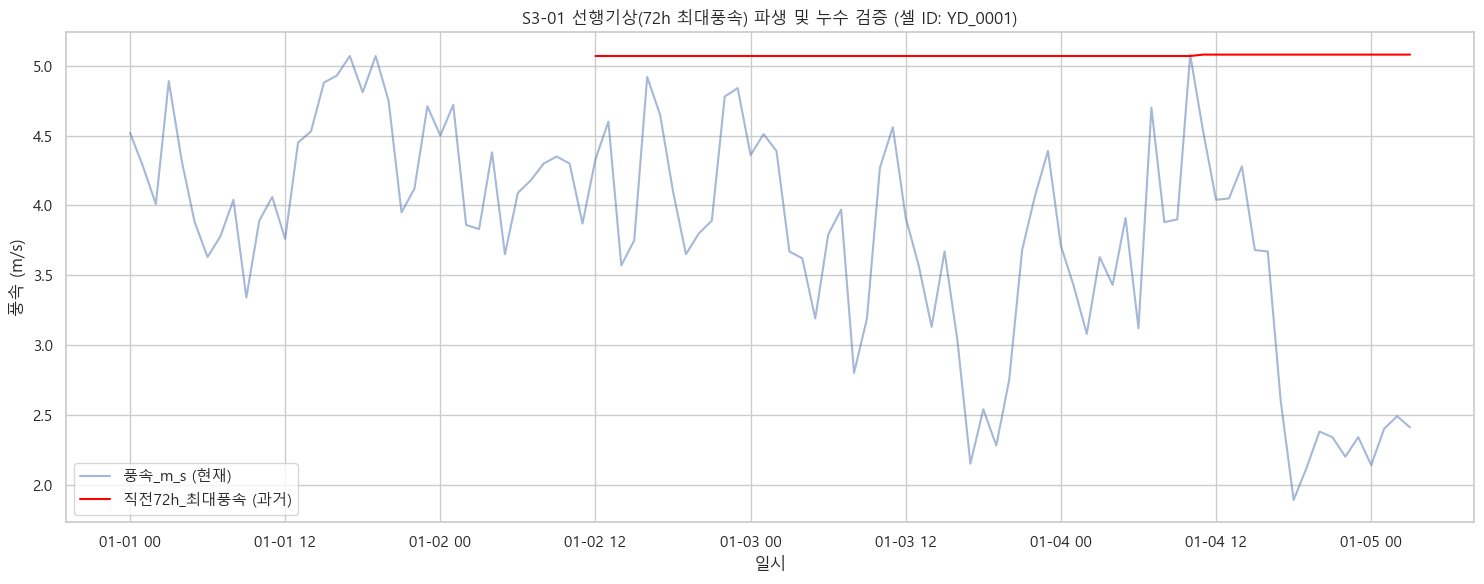

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))
plt.plot(sample_df['일시'], sample_df['풍속_m_s'], label='풍속_m_s (현재)', alpha=0.5)
plt.plot(sample_df['일시'], sample_df['직전72h_최대풍속'], label='직전72h_최대풍속 (과거)', color='red')
plt.title(f'S3-01 선행기상(72h 최대풍속) 파생 및 누수 검증 (셀 ID: {sample_cell})')
plt.xlabel('일시')
plt.ylabel('풍속 (m/s)')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/Step3/plots/S3-01_lead_time_series.png', dpi=150)
plt.show()


## [S3-02] 선행시간별 산불-매칭 대조 위험 delta
동일 기상셀, 월, 시간대(Hour)를 공유하는 비발생 대조군을 산불당 최대 5건씩 매칭하여,
시점부터 과거 72시간, D-1~D-3까지의 선행시간별 기상 변수의 위험 delta와 효과크기(Cohen's dz)를 산출한다.

In [12]:
import scipy.stats as stats

# 매칭 비발생 대조군 생성
# fire_points 공간 조인을 통해 기상셀ID 획득
import geopandas as gpd
fire_joined = gpd.sjoin(fire_points, weather_grid, how='left', predicate='within')
fire_matched = fire_joined.dropna(subset=['기상셀ID']).copy()
fire_matched['기준시각'] = pd.to_datetime(fire_matched['기준시각'])
fire_events = set(zip(fire_matched['기상셀ID'], fire_matched['기준시각']))

hourly_weather['is_fire'] = hourly_weather.apply(lambda row: (row['기상셀ID'], row['일시']) in fire_events, axis=1)
non_fire_candidates = hourly_weather[~hourly_weather['is_fire']].copy()
non_fire_candidates['월'] = non_fire_candidates['일시'].dt.month
non_fire_candidates['시간'] = non_fire_candidates['일시'].dt.hour

grouped_candidates = non_fire_candidates.groupby(['기상셀ID', '월', '시간'])

matched_controls = []
np.random.seed(42)

WEATHER_VARS = [
    '시점_풍속_m_s', '시점_습도_pct', 
    '직전24h_평균풍속', '직전24h_최소습도',
    '직전48h_평균풍속', '직전48h_최소습도',
    '직전72h_평균풍속', '직전72h_최소습도',
    'D-1_최소습도_pct', 'D-2_최소습도_pct', 'D-3_최소습도_pct'
]

for idx, row in fire_matched.iterrows():
    f_cell = row['기상셀ID']
    f_time = row['기준시각']
    key = (f_cell, f_time.month, f_time.hour)
    
    if key in grouped_candidates.groups:
        group_indices = grouped_candidates.groups[key]
        candidates_for_fire = non_fire_candidates.loc[group_indices]
        n_sample = min(5, len(candidates_for_fire))
        sampled = candidates_for_fire.sample(n=n_sample, replace=False)
        
        for _, s_row in sampled.iterrows():
            control_dict = {
                'fire_id': row['fire_id'],
                '대조_기상셀ID': s_row['기상셀ID'],
                '대조_일시': s_row['일시']
            }
            for col in WEATHER_VARS:
                control_dict[f'control_{col}'] = s_row[col]
            matched_controls.append(control_dict)

matched_df = pd.DataFrame(matched_controls)
agg_dict = {f'control_{v}': 'mean' for v in WEATHER_VARS}
control_agg = matched_df.groupby('fire_id').agg(agg_dict).reset_index()

fire_weather = fire_matched[['fire_id', '기상셀ID', '기준시각']].rename(columns={'기준시각': '일시'})
fire_weather = fire_weather.merge(hourly_weather[['기상셀ID', '일시'] + WEATHER_VARS], on=['기상셀ID', '일시'], how='inner')

paired_df = fire_weather.merge(control_agg, on='fire_id', how='inner')

for var in WEATHER_VARS:
    paired_df[f'delta_{var}'] = paired_df[var] - paired_df[f'control_{var}']

paired_df = paired_df.dropna(subset=[f'delta_{v}' for v in WEATHER_VARS])
print("매칭 완료. 분석에 사용 가능한 산불 건수:", len(paired_df))


매칭 완료. 분석에 사용 가능한 산불 건수: 3395


In [13]:
from statsmodels.stats.multitest import fdrcorrection

def cohens_dz(d):
    return d.mean() / d.std(ddof=1)

results = []
for var in WEATHER_VARS:
    delta_col = f'delta_{var}'
    d = paired_df[delta_col]
    
    # 대응표본 t-검정
    t_stat, p_val = stats.ttest_1samp(d, 0)
    
    # 95% CI
    mean_d = d.mean()
    se = d.std(ddof=1) / np.sqrt(len(d))
    ci_low, ci_high = stats.t.interval(0.95, len(d)-1, loc=mean_d, scale=se)
    
    dz = cohens_dz(d)
    
    results.append({
        '변수': var,
        '산불_평균': paired_df[var].mean(),
        '대조_평균': paired_df[f'control_{var}'].mean(),
        'Delta_Mean': mean_d,
        'CI_95_Low': ci_low,
        'CI_95_High': ci_high,
        't_stat': t_stat,
        'p_value': p_val,
        'Cohens_dz': dz
    })

res_df = pd.DataFrame(results)
_, res_df['FDR_p'] = fdrcorrection(res_df['p_value'])

res_df = res_df.sort_values(by='Cohens_dz', key=abs, ascending=False)
res_df.to_csv('outputs/Step3/tables/S3-02_lead_time_delta.csv', index=False, encoding='utf-8-sig')
display(res_df)


,변수,산불_평균,대조_평균,Delta_Mean,CI_95_Low,CI_95_High,t_stat,p_value,Cohens_dz,FDR_p
3,직전24h_최소습도,32.909935,41.158795,-8.248860,-8.679181,-7.818539,-37.584098,8.842027e-259,-0.645036,9.726230e-258
5,직전48h_최소습도,30.053685,36.361345,-6.307660,-6.678197,-5.937123,-33.376382,1.777504e-211,-0.572822,9.776274e-211
8,D-1_최소습도_pct,34.529502,42.571139,-8.041637,-8.532623,-7.550652,-32.112844,8.250561e-198,-0.551136,3.025206e-197
7,직전72h_최소습도,28.002418,33.617545,-5.615127,-5.963146,-5.267107,-31.634366,1.044597e-192,-0.542924,2.872641e-192
1,시점_습도_pct,49.703670,56.368378,-6.664708,-7.329652,-5.999763,-19.651633,1.617343e-81,-0.337271,3.558155e-81
10,D-3_최소습도_pct,37.962630,42.584399,-4.621768,-5.172325,-4.071212,-16.459233,1.270189e-58,-0.282481,2.328680e-58
9,D-2_최소습도_pct,38.808539,42.542841,-3.734302,-4.248377,-3.220228,-14.242512,9.479552e-45,-0.244437,1.489644e-44
2,직전24h_평균풍속,2.119961,1.974381,0.145580,0.116902,0.174258,9.953094,5.039520e-23,0.170820,6.929339e-23
4,직전48h_평균풍속,2.072737,1.971390,0.101346,0.078971,0.123721,8.880556,1.056551e-18,0.152412,1.291341e-18
6,직전72h_평균풍속,2.038128,1.969671,0.068457,0.048744,0.088169,6.808859,1.158623e-11,0.116857,1.274485e-11


C:\Users\swoo6\AppData\Local\Temp\ipykernel_17992\1029561416.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df.loc[order].reset_index(), x='Cohens_dz', y='변수', palette='coolwarm')


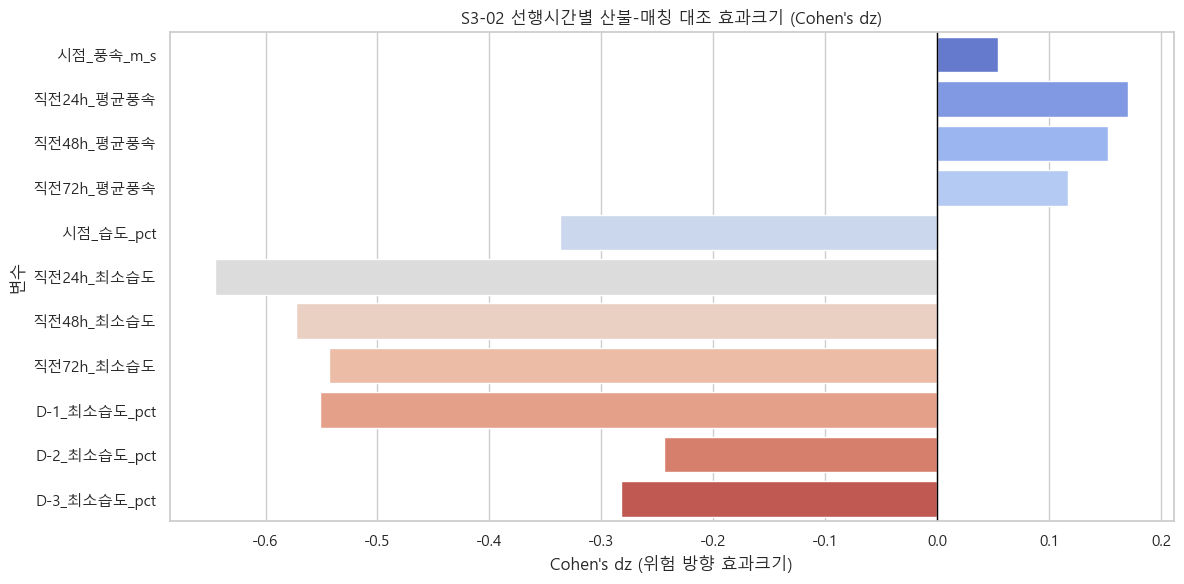

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# 변수명을 시간창순으로 정렬
wind_vars = ['시점_풍속_m_s', '직전24h_평균풍속', '직전48h_평균풍속', '직전72h_평균풍속']
hum_vars = ['시점_습도_pct', '직전24h_최소습도', '직전48h_최소습도', '직전72h_최소습도', 'D-1_최소습도_pct', 'D-2_최소습도_pct', 'D-3_최소습도_pct']

plot_df = res_df.set_index('변수')
order = wind_vars + hum_vars

sns.barplot(data=plot_df.loc[order].reset_index(), x='Cohens_dz', y='변수', palette='coolwarm')
plt.title('S3-02 선행시간별 산불-매칭 대조 효과크기 (Cohen\'s dz)')
plt.xlabel("Cohen's dz (위험 방향 효과크기)")
plt.ylabel('변수')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.savefig('outputs/Step3/plots/S3-02_lead_time_dz_barplot.png', dpi=150)
plt.show()
